<a href="https://colab.research.google.com/github/UnnatPar/UW417-Labs/blob/main/Lab2_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2 Report:
## Iris Classification with Regression

### Name: Unnat Parsana

In [ ]:
# Import neccessary packages

%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

In [ ]:
from IPython.display import Image # For displaying images in colab jupyter cell

In [ ]:
Image('lab2_exercise1.png', width = 1000)

FileNotFoundError: No such file or directory: 'lab2_exercise1.png'

FileNotFoundError: No such file or directory: 'lab2_exercise1.png'

<IPython.core.display.Image object>

## Prepare Data

In [ ]:
from sklearn.datasets import load_iris

# iris dataset is available from scikit-learn package
iris = load_iris()

# Load the X (features) and y (targets) for training
X_train = iris['data']
y_train = iris['target']

# Load the name labels for features and targets
feature_names = iris['feature_names']
names = iris['target_names']

# Feel free to perform additional data processing here (e.g. standard scaling)

In [ ]:
# Print the first 10 training samples for both features and targets

print(X_train[:10, :], y_train[:10])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]] [0 0 0 0 0 0 0 0 0 0]


In [ ]:
# Print the dimensions of features and targets

print(X_train.shape, y_train.shape)

(150, 4) (150,)


In [ ]:
# feature_names contains name for each column in X_train
# For targets, 0 -> setosa, 1 -> versicolor, 2 -> virginica

print(feature_names, names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'] ['setosa' 'versicolor' 'virginica']


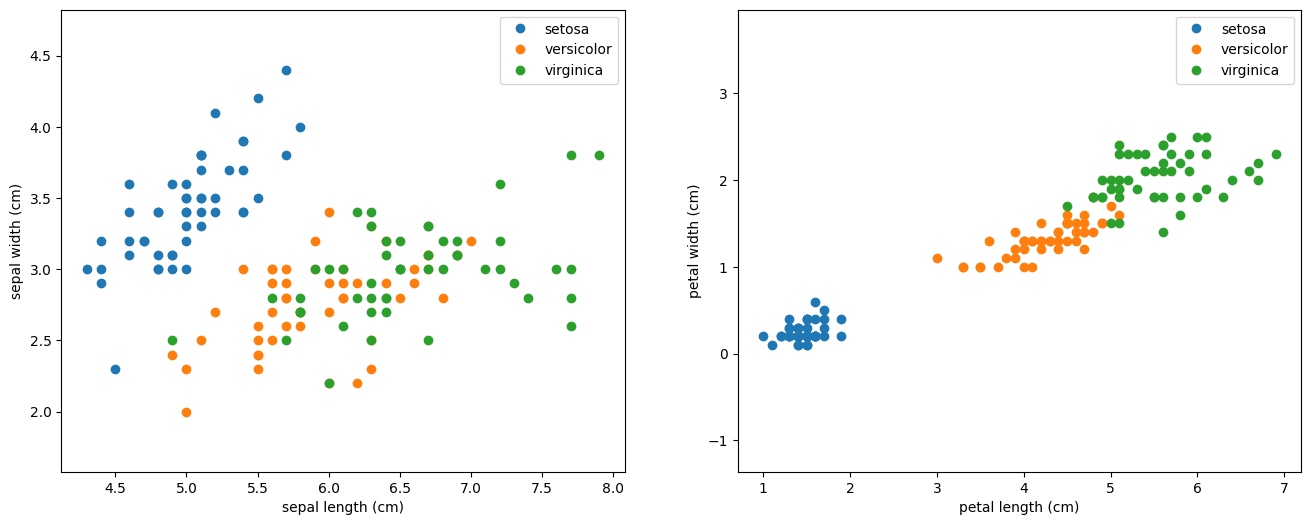

In [ ]:
# We can visualize the dataset before training

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# enumerate picks up both the index (0, 1, 2) and the element ('setosa', 'versicolor', 'virginica') from "names"
# loop 1: target = 0, target_name = 'setosa'
# loop 2: target = 1, target_name = 'versicolor' etc

for target, target_name in enumerate(names):

    # Subset the rows of X_train that fall into each flower category using boolean mapping
    X_plot = X_train[y_train == target]

    # Plot the sepal length versus sepal width for the flower category
    ax1.plot(X_plot[:, 0], X_plot[:, 1], linestyle='none', marker='o', label=target_name)

# Label the plot
ax1.set_xlabel(feature_names[0])
ax1.set_ylabel(feature_names[1])
ax1.axis('equal')
ax1.legend()

# Repeat the above process but with petal length versus petal width
for target, target_name in enumerate(names):

    X_plot = X_train[y_train == target]

    ax2.plot(X_plot[:, 2], X_plot[:, 3], linestyle='none', marker='o', label=target_name)

ax2.set_xlabel(feature_names[2])
ax2.set_ylabel(feature_names[3])
ax2.axis('equal')
ax2.legend()

## Define Model

In [ ]:
import torch.nn as nn

class irisClassification(nn.Module):

    def __init__(self, input_dim, output_dim):

        super(irisClassification, self).__init__()

        self.layerInitial = nn.Linear(input_dim, 32)
        self.layerMid = nn.Linear(32, 32)
        self.layerFinal = nn.Linear(32, output_dim) # Output dimension is 1 for regression with MSE
        self.relu = nn.ReLU()
        # self.softmax = nn.Softmax(dim=1) # Softmax is not needed for regression

    def forward(self, x):


        x = self.layerInitial(x)
        x = self.layerMid(x)
        x = self.layerFinal(x)

        return x # Return the raw output for MSE

## Define Hyperparameters

In [ ]:
model = irisClassification(4, 1) # Output dimension is 1 for regression with MSE

learning_rate = 0.0015
epochs  = 49

# trainloader = DataLoader(iris, batch_size = 20, shuffle = True) # Removed incorrect DataLoader initialization

# We will use gradient descent for our optimizer and Mean Squared Error Loss function
loss_func = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)

## Identify Tracked Values

In [ ]:
# follow models performance over each epoch. Identify a metric and track it over epochs

from torch.utils.data import Dataset
import torch.nn as nn
import torch.nn.functional as F # Import functional for one_hot
from torch.utils.data import DataLoader # Import DataLoader explicitly

class IrisDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create an instance of the custom dataset
train_dataset = IrisDataset(X_train, y_train)
print(len(train_dataset))

# Update the DataLoader to use the custom dataset
trainloader = DataLoader(train_dataset, batch_size=20, shuffle=True)

# We will use gradient descent for our optimizer and Mean Squared Error Loss function
loss_func = torch.nn.MSELoss()

150


## Train Model

In [ ]:
accuracies = []
losses = []
epoch_list = range(epochs)
total_predicted_counts = torch.zeros(3) # Initialize a tensor to store total predicted counts

# Define Mean Squared Error Loss
loss_func = torch.nn.MSELoss()


for epoch in range(epochs):
    total_correct = 0
    total_samples = 0
    for inputs, labels in trainloader:
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        # print(outputs) # Removed verbose printing during training

        # Calculate loss - Use MSE Loss
        loss = loss_func(outputs.squeeze(), labels.float()) # Ensure outputs is 1D and labels are float

        # Backward pass
        loss.backward()

        # Optimize the weights
        optimizer.step()

        # Calculate training accuracy by rounding the output
        predicted = torch.round(outputs.squeeze()) # Round the output to the nearest integer
        total_samples += labels.size(0)
        total_correct += (predicted == labels.float()).sum().item() # Compare rounded prediction to float labels

        # Aggregate predicted counts using the rounded predicted values
        total_predicted_counts += torch.bincount(predicted.long(), minlength=3) # Convert to long for bincount


    # Append the loss and accuracy *after* the inner batch loop finishes
    losses.append(loss.item())
    accuracy = 100 * total_correct / total_samples
    accuracies.append(accuracy / 100) # Append accuracy as a value between 0 and 1
    print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, Training Accuracy: {accuracy:.2f}%')

print("\nTotal predicted class counts across all epochs:", total_predicted_counts)

Epoch 1/49, Loss: 0.0581, Training Accuracy: 96.00%
Epoch 2/49, Loss: 0.0540, Training Accuracy: 97.33%
Epoch 3/49, Loss: 0.0933, Training Accuracy: 96.67%
Epoch 4/49, Loss: 0.0734, Training Accuracy: 96.67%
Epoch 5/49, Loss: 0.0352, Training Accuracy: 96.67%
Epoch 6/49, Loss: 0.0356, Training Accuracy: 98.00%
Epoch 7/49, Loss: 0.0920, Training Accuracy: 96.00%
Epoch 8/49, Loss: 0.0834, Training Accuracy: 96.00%
Epoch 9/49, Loss: 0.0657, Training Accuracy: 96.00%
Epoch 10/49, Loss: 0.0481, Training Accuracy: 97.33%
Epoch 11/49, Loss: 0.0795, Training Accuracy: 98.00%
Epoch 12/49, Loss: 0.0932, Training Accuracy: 98.00%
Epoch 13/49, Loss: 0.0611, Training Accuracy: 96.00%
Epoch 14/49, Loss: 0.0686, Training Accuracy: 96.00%
Epoch 15/49, Loss: 0.0830, Training Accuracy: 96.00%
Epoch 16/49, Loss: 0.0894, Training Accuracy: 96.67%
Epoch 17/49, Loss: 0.0487, Training Accuracy: 97.33%
Epoch 18/49, Loss: 0.0542, Training Accuracy: 95.33%
Epoch 19/49, Loss: 0.0542, Training Accuracy: 96.67%
Ep

## Visualize and Evaluate Model

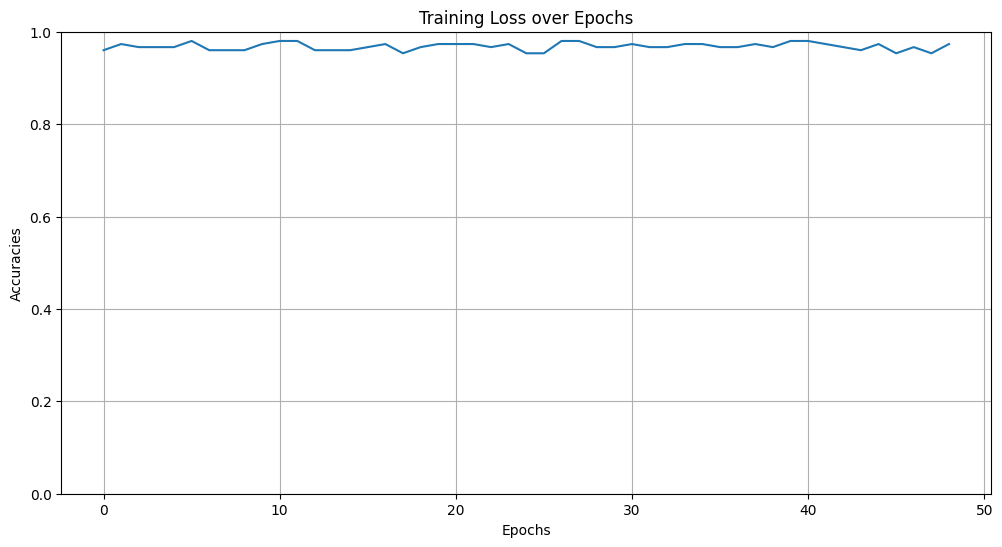

In [ ]:
# Plot your training loss throughout the training
# Include proper x and y labels for the plot

plt.figure(figsize=(12, 6))

# Ensure losses are floats for plotting
losses_plot = [float(loss_item) for loss_item in losses]

plt.plot(epoch_list, accuracies) # Plot losses against epochs
plt.ylim(0,1)
plt.xlabel("Epochs")
plt.ylabel("Accuracies")
plt.title("Training Loss over Epochs")
plt.grid(True)
plt.show()

In [ ]:
# Confirm that your model's training accuracy is >90%

with torch.no_grad():

    # Compare your model predictions with targets (y_train) to compute the training accuracy
    # YOUR CODE HERE

# Training accuracy = (# of correct predictions) / (total # of training samples)
# You can round the model predictions to integer (e.g. 0.34 -> 0, 1.78 -> 2)

# YOUR CODE HERE

#Code was implemented in model above - note from Unnat